In [84]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from redpitaya_control.redpitaya_dev import redpitaya_dev
from redpitaya_control.event_logger import EventLogger, unpack, load_run, fit_clock, counter_to_unix
from redpitaya_control import compute_coeff


import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

from scipy.optimize import curve_fit
from scipy.special import factorial


from pathlib import Path
import matplotlib.pyplot as plt


runfiles = ['time_analysis','time_analysis_new_source_ten_minute']#_ten_minutes'] ##OLD, NEW

MAX_Q15 = 32767 / 32768
C1 = 99.90741625
C2 = 1225.60912165
C3 = 1024.0
C4 = 14.4



MAX_Q15 = 32767 / 32768


In [85]:
import numpy as np

# Your known calibration points
cal_adu = np.array([450, 1243, 12216])
cal_kev = np.array([6.395, 14.4129, 122.06])

# Calculate the quadratic fit (2nd-degree polynomial)
a, b, c = np.polyfit(cal_adu, cal_kev, deg=2)

print(f"a = {a:e}")
print(f"b = {b:e}")
print(f"c = {c:e}")


def adu_to_kev(adu):

    a = -2.555374e-08
    b = 1.015411e-02
    c = 1.830826e+00
    
    return a * (adu ** 2) + b * adu + c


def kev_to_adu(kev):
    a = -2.555374e-08
    b = 1.015411e-02
    c = 1.830826e+00
    
    # Calculate ADU using the positive root of the quadratic formula
    adu = (-b + np.sqrt(b**2 - 4 * a * (c - kev))) / (2 * a)
    
    return adu




a = -2.555374e-08
b = 1.015411e-02
c = 1.830826e+00


In [86]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# --- Data Loading ---
raw = load_run(f"{runfiles[0]}/events_*.bin")
ts_us_old, energy_old, _ = unpack(raw)

print(
    f"{len(ts_us_old)} events, span {(ts_us_old[-1]-ts_us_old[0])/1e6:.1f} s"
    if len(ts_us_old) > 1
    else "no events"
)
a, b, ppm = fit_clock(f"{runfiles[0]}/tiepoints.csv")
print(f"Crystal drift: {ppm:+.1f} ppm")
t_unix_old = counter_to_unix(ts_us_old, a, b)


raw = load_run(f"{runfiles[1]}/events_*.bin")
ts_us_new, energy_new, chb = unpack(raw)
print(
    f"{len(ts_us_new)} events, span {(ts_us_new[-1]-ts_us_new[0])/1e6:.1f} s"
    if len(ts_us_new) > 1
    else "no events"
)

a, b, ppm = fit_clock(f"{runfiles[1]}/tiepoints.csv")
print(f"Crystal drift: {ppm:+.1f} ppm")
t_unix_new = counter_to_unix(ts_us_new, a, b)


807516 events, span 599.6 s
Crystal drift: -1.0 ppm
524395 events, span 599.0 s
Crystal drift: +16.0 ppm


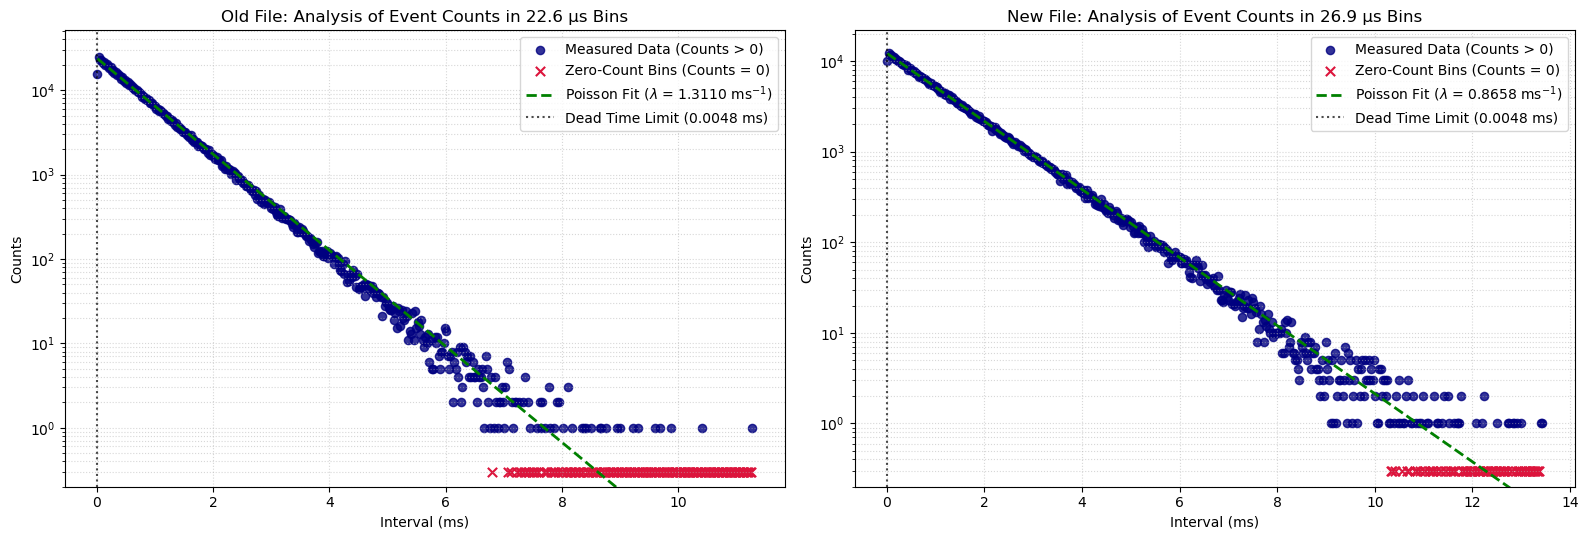

In [87]:


# --- Plotting Side-by-Side ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

data_runs = [
    (ts_us_old, "Old File", axes[0]),
    (ts_us_new, "New File", axes[1]),
]

for ts_us, label_prefix, ax in data_runs:
    # 1. Compute time differences in milliseconds
    times_ms = np.asarray(ts_us, dtype=np.int64) / 1e3  # Converted to ms
    dt_ms = np.diff(times_ms)

    # 2. Histogram with bin centers
    bins = 500
    counts, bin_edges = np.histogram(dt_ms, bins=bins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width = bin_edges[1] - bin_edges[0]  # Bin width in ms

    # 3. Isolate valid region above dead time cutoff (4.8 us = 0.0048 ms)
    dead_time_ms = 4.8 / 1e3
    mask = bin_centers > dead_time_ms

    fit_x = bin_centers[mask]
    fit_y = counts[mask]
    N_valid = np.sum(fit_y)  # Total counts in the valid region

    # Normalized 1-parameter exponential model
    def exp_func(
        dt,
        lmbda,
        N_valid=N_valid,
        bin_width=bin_width,
        dead_time_ms=dead_time_ms,
    ):
        return N_valid * bin_width * lmbda * np.exp(-lmbda * (dt - dead_time_ms))

    # Fit the single parameter lambda (p0 adjusted for ms scale)
    popt, pcov = curve_fit(
        exp_func,
        fit_x,
        fit_y,
        p0=[1.0],
    )
    fit_lambda = popt[0]  # in ms^-1
    fit_lambda_err = np.sqrt(pcov[0, 0])

    # 4. Plotting
    nonzero_mask = counts > 0
    zero_mask = counts == 0

    # Plot non-zero count bins
    ax.scatter(
        bin_centers[nonzero_mask],
        counts[nonzero_mask],
        color="navy",
        alpha=0.8,
        s=35,
        label="Measured Data (Counts > 0)",
    )

    # Plot zero-count bins explicitly on the log baseline
    baseline_zero_y = 0.3
    ax.scatter(
        bin_centers[zero_mask],
        np.full(np.sum(zero_mask), baseline_zero_y),
        color="crimson",
        marker="x",
        s=45,
        linewidth=1.5,
        label="Zero-Count Bins (Counts = 0)",
    )

    # Plot exponential fit curve
    ax.plot(
        fit_x,
        exp_func(fit_x, *popt),
        "g--",
        linewidth=2,
        label=f"Poisson Fit ($\lambda$ = {fit_lambda:.4f} $\mathrm{{ms}}^{{-1}}$)",
    )

    # Dead time threshold vertical line
    ax.axvline(
        dead_time_ms,
        color="black",
        linestyle=":",
        alpha=0.7,
        label=f"Dead Time Limit ({dead_time_ms:.4f} ms)",
    )

    ax.set_yscale("log")
    ax.set_ylim(bottom=0.2)
    ax.set_xlabel(r"Interval (ms)")  # Updated axis label
    ax.set_ylabel("Counts")
    ax.set_title(
        f"{label_prefix}: Analysis of Event Counts in {bin_width * 1e3:.1f} µs Bins"
    )
    ax.legend()
    ax.grid(True, which="both", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

energy_datasets = [
    (energy_old, "Old Energy Spectrum", axes[0]),
    (energy_new, "New Energy Spectrum", axes[1]),
]

for energy, title, ax in energy_datasets:
    adu = range(int(max(energy)) + 1)
    ax.hist(energy, bins=adu, log=True)
    ax.set_title(title)
    ax.set_xlabel("Energy / ADC Channel")
    ax.set_ylabel("Counts (log scale)")
    ax.set_xlim(kev_to_adu(13.3),kev_to_adu(15.5))

plt.tight_layout()
plt.show()


[File 1] Found 305693 events in the 6.2 - 6.6 keV range.
Grouped into 5997 100.0-ms intervals.
Max events in a single 100.0-ms interval: 76
Variance/Mean Ratio: 0.977  (Ideal: ~1.0)
Chi-Squared (χ²): 40.854
Reduced Chi-Squared (χ²/dof): 0.851
Fitted Lambda (λ): 51.096
nonzero counts: 50


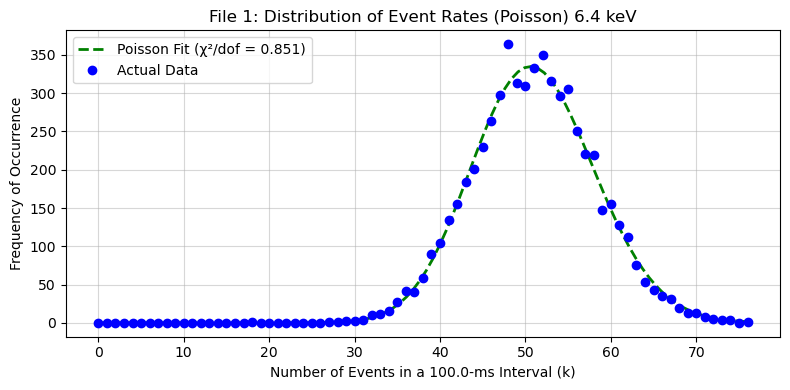

[File 2] Found 210051 events in the 13.3 - 15.5 keV range.
Grouped into 11980 50.0-ms intervals.
Max events in a single 50.0-ms interval: 35
Variance/Mean Ratio: 0.981  (Ideal: ~1.0)
Chi-Squared (χ²): 41.125
Reduced Chi-Squared (χ²/dof): 1.327
Fitted Lambda (λ): 17.497
nonzero counts: 32


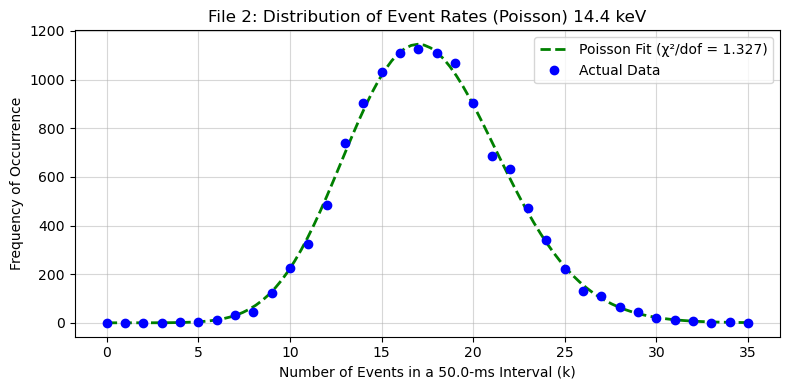

[File 1] Found 221 events in the 120 - 124 keV range.
Grouped into 29 21000.0-ms intervals.
Max events in a single 21000.0-ms interval: 14
Variance/Mean Ratio: 0.727  (Ideal: ~1.0)
Chi-Squared (χ²): 15.516
Reduced Chi-Squared (χ²/dof): 1.552
Fitted Lambda (λ): 7.803
nonzero counts: 9


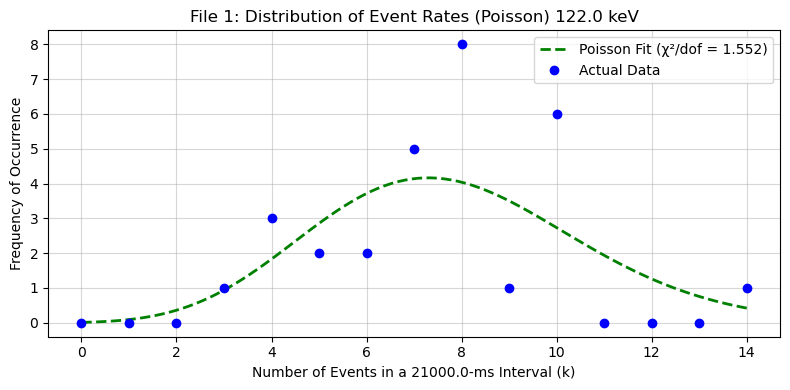

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.special import factorial


def graph_poissonian(
    e_start=14.2, e_end=14.6, bin=100000, file=1, save=False
):
    # Select dataset based on file parameter
    if file == 1:
        energy_data = energy_old
        ts_us_data = ts_us_old
        file_label = "File 1"
    elif file == 2:
        energy_data = energy_new
        ts_us_data = ts_us_new
        file_label = "File 2"
    else:
        raise ValueError("Parameter 'file' must be 1 or 2.")

    energy_kev = adu_to_kev(energy_data)

    # Filter for the e_start - e_end keV range
    mask = (energy_kev >= e_start) & (energy_kev <= e_end)

    filtered_energies = energy_kev[mask]
    filtered_times_us = ts_us_data[mask]

    if len(ts_us_data) > 0:
        start_time = ts_us_data[ts_us_data > 0][0]
        end_time = ts_us_data[-1]

        # Bin time intervals
        time_bins = np.arange(start_time, end_time + bin, bin)

        frequencies, _ = np.histogram(filtered_times_us, bins=time_bins)
        interval_timestamps = time_bins[:-1]

        print(
            f"[{file_label}] Found {len(filtered_energies)} events in the {e_start} - {e_end} keV range."
        )
        print(f"Grouped into {len(frequencies)} {bin/(1e3)}-ms intervals.")
        print(
            f"Max events in a single {bin/(1e3)}-ms interval: {np.max(frequencies)}"
        )

    else:
        print(f"[{file_label}] No events to process.")
        filtered_energies = np.array([])
        filtered_times_us = np.array([])
        frequencies = np.array([])
        interval_timestamps = np.array([])
        return

    max_count = int(np.max(frequencies))
    integer_bins = np.arange(-0.5, max_count + 1.5, 1.0)

    # Calculate histogram
    counts, bin_edges = np.histogram(frequencies, bins=integer_bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Define the Poisson PMF
    def poisson_pmf(k, lmbda):
        total_intervals = len(frequencies)
        return total_intervals * ((lmbda**k * np.exp(-lmbda)) / factorial(k))

    # Perform the curve fit
    popt, pcov = curve_fit(
        poisson_pmf, bin_centers, counts, p0=[np.mean(frequencies)]
    )
    fit_lambda = popt[0]

    fit_x = np.linspace(0, max_count, 100)

    # Plotting
    plt.figure(figsize=(8, 4))

    observed = counts
    expected = poisson_pmf(bin_centers, *popt)

    valid_bins = expected > 0.5
    obs = observed[valid_bins]
    exp = expected[valid_bins]
    sigma = np.sqrt(exp)

    chi_squared = np.sum(((obs - exp) / sigma) ** 2)
    n_params = len(popt)
    dof = len(obs) - n_params
    reduced_chi_squared = chi_squared / dof if dof > 0 else np.nan

    sample_mean = np.mean(frequencies)
    sample_var = np.var(frequencies)
    dispersion = sample_var / sample_mean if sample_mean > 0 else 0

    print(f"Variance/Mean Ratio: {dispersion:.3f}  (Ideal: ~1.0)")
    print(f"Chi-Squared (χ²): {chi_squared:.3f}")
    print(f"Reduced Chi-Squared (χ²/dof): {reduced_chi_squared:.3f}")
    print(f"Fitted Lambda (λ): {fit_lambda:.3f}")
    print(f"nonzero counts: {len(counts[counts>0])}")

    plt.plot(
        fit_x,
        poisson_pmf(fit_x, *popt),
        "g--",
        linewidth=2,
        label=f"Poisson Fit (χ²/dof = {reduced_chi_squared:.3f})",
    )

    plt.plot(
        bin_centers,
        counts,
        marker="o",
        linestyle="",
        color="blue",
        label="Actual Data",
    )

    average_kev = np.average([e_end, e_start])
    plt.title(
        f"{file_label}: Distribution of Event Rates (Poisson) {average_kev:.1f} keV"
    )
    plt.xlabel(f"Number of Events in a {bin/(1e3)}-ms Interval (k)")
    plt.ylabel("Frequency of Occurrence")

    plt.legend()
    plt.grid(True, alpha=0.5)
    plt.tight_layout()

    if save:
        base_path = Path(f"poisson_fit_{file_label}_kev_{average_kev:.1f}.png")
        stem = base_path.stem
        suffix = base_path.suffix
        parent = base_path.parent

        save_path = base_path
        counter = 1

        while save_path.exists():
            save_path = parent / f"{stem}_{counter}{suffix}"
            counter += 1
        plt.savefig(save_path, transparent=True, bbox_inches="tight")
        print(f"Saved figure to: {save_path}")

    plt.show()


# Example usage:
# graph_poissonian(e_start=6.2, e_end=6.6, bin=1e5, file=1)
graph_poissonian(e_start=13.3, e_end=15.5, bin=5e4, file=1)

graph_poissonian(e_start=13.3, e_end=15.5, bin=5e4, file=2)
# graph_poissonian(e_start=120, e_end=124, bin=2.1e7, file=1)


In [ ]:

times = np.asarray(ts_us, dtype=np.float64)   # seconds
adu = np.asarray(energy, dtype=np.int32)

dt = np.diff(times)
dadu = np.diff(adu)
abs_dadu = np.abs(dadu)

# Select time-spacing groups
nonzero_mask = dt > 0
zero_mask = np.isclose(dt, 0.0, atol=1e-9)



def summarize(label, mask):
    values = abs_dadu[mask]

    if values.size == 0:
        print(f"{label}: no matching pairs")
        return

    mean_abs = np.mean(values)
    max_abs = np.max(values)

    print(f"{label}")
    print(f"  Number of pairs:       {values.size}")
    print(f"  Mean absolute ΔkeV:    {adu_to_kev(mean_abs):.3f}")
    print(f"  Max absolute ΔkeV:  {adu_to_kev(max_abs):.3f}")









summarize("Δt = 0", zero_mask)
summarize("Δt > 0", nonzero_mask)


Δt = 0
  Number of pairs:       145
  Mean absolute ΔkeV:    17.334
  Max absolute ΔkeV:  107.429
Δt > 0
  Number of pairs:       524249
  Mean absolute ΔkeV:    23.663
  Max absolute ΔkeV:  216.011
